# Retail Demand Modeling: Price and Promotion Drivers with Validation-Based Variable Selection


## Executive Summary

A retail analytics team models weekly SKU-level unit sales as a function of price, promotional levers, marketing spend, and seasonality across product categories. `PROC GLMSELECT` fits a linear regression with stepwise variable selection over a train/validate/test partition, letting validation-based selection guard against over-fitting before the demand model informs pricing and promotion planning. `PROC REG` then re-fits a focused model to report interpretable estimates, multicollinearity diagnostics, and observation-level predictions.

## Data Sources

| Dataset | Rows | Grain | Key Variables | Description |
|---------|------|-------|---------------|-------------|
| `weekly_sales` | 100 | store-week-SKU | `units` (response), `price`, `base_price`, `discount_pct`, `promo` (display/feature/none), `email_spend`, `social_spend`, `comp_price`, `holiday`, `week_of_year`, `category` (Grocery/Beverage/Snack/HouseHold), `role` (TRAIN/VAL/TEST) | Synthetic point-of-sale panel: weekly unit sales per SKU driven by own-price elasticity, promotional uplift, marketing spend, competitor pricing, and holiday/seasonal effects, generated inline with `call streaminit` + `rand()`. |

# Retail Demand Modeling with Validation-Based Selection

A category manager at a consumer-goods retailer wants to understand which levers actually move **weekly unit sales** at the SKU level: own price, the depth of any temporary price reduction, the type of in-store promotion, digital marketing spend, competitor pricing, and seasonal/holiday effects.

With dozens of candidate effects (including category interactions), the risk is over-fitting. `PROC GLMSELECT` is purpose-built for this: it fits ordinary least squares and performs principled **variable selection** with a held-out **validation** partition so the chosen model generalizes. (`GLMSELECT` is the selection engine that SAS high-performance regression builds on; the workflow below is exactly what an analyst would run in Base SAS/STAT.) This notebook generates a realistic synthetic point-of-sale panel, then fits a demand model the way a SAS analyst would in practice.

## Step 1 — Generate a synthetic point-of-sale panel

We simulate a panel of store-week-SKU observations across four product categories. Unit sales follow a plausible demand structure:

- **Own price** depresses demand (negative elasticity), with a percentage discount off base price driving the largest temporary swings.
- **Promotion type** (display, feature, or none) adds multiplicative uplift.
- **Email and social marketing spend** add modest lift with diminishing returns.
- **Competitor price** raises our demand when rivals are expensive.
- **Holiday weeks** and a smooth **seasonal** term shift the baseline.

We assign each row to TRAIN / VAL / TEST roles so selection can be validated. The seed makes the data reproducible.

In [1]:
data weekly_sales;
    call streaminit(20260531);
    length category $9 promo $7 role $5;
    array catbase{4} _temporary_ (180 240 150 120);
    do i = 1 to 100;
        /* product category */
        c = rand('table', 0.30, 0.25, 0.25, 0.20);
        if      c = 1 then category = 'Grocery';
        else if c = 2 then category = 'Beverage';
        else if c = 3 then category = 'Snack';
        else               category = 'HouseHold';

        /* pricing: base price and a temporary price reduction.
           45% of items carry a 0-40% discount; the rest are 0. */
        base_price   = round(2 + rand('uniform') * 8, 0.01);
        discount_pct = ifn(rand('uniform') < 0.45,
                           round(rand('uniform') * 0.40, 0.01),
                           0);
        price = round(base_price * (1 - discount_pct), 0.01);

        /* competitor price near our base price */
        comp_price = round(base_price * (0.85 + rand('uniform') * 0.30), 0.01);

        /* in-store promotion type */
        p = rand('table', 0.55, 0.25, 0.20);
        if      p = 1 then promo = 'None';
        else if p = 2 then promo = 'Display';
        else               promo = 'Feature';

        /* digital marketing spend (in $00s), right-skewed */
        email_spend  = round(rand('exponential') * 3, 0.1);
        social_spend = round(rand('exponential') * 2, 0.1);

        /* seasonality */
        week_of_year = 1 + int(rand('uniform') * 52);
        season = 12 * sin(2 * constant('pi') * week_of_year / 52);
        holiday = (week_of_year in (47 48 51 52));

        /* demand model (data-generating process) */
        promo_lift = (promo = 'Display') * 35
                   + (promo = 'Feature') * 60;
        mu = catbase{c}
           + 220 * discount_pct
           - 9   * price
           + 6   * comp_price
           + promo_lift
           + 8   * log(1 + email_spend)
           + 5   * log(1 + social_spend)
           + 18  * holiday
           + season
           + 25  * discount_pct * (promo = 'Feature');

        units = round(mu + rand('normal') * 18);
        if units < 0 then units = 0;

        /* train / validate / test partition */
        u = rand('uniform');
        if      u < 0.60 then role = 'TRAIN';
        else if u < 0.80 then role = 'VAL';
        else                  role = 'TEST';

        output;
    end;
    drop i c p u mu promo_lift season;
run;

NOTE: DATA weekly_sales


NOTE: Wrote weekly_sales (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 — Inspect the simulated data

A quick look at the first observations and category-level means confirms the data is shaped the way a retail panel should be: discounts cluster around promotional events, and average units differ by category and promotion type.

In [2]:
proc print data=weekly_sales(obs=8) noobs;
    var category price base_price discount_pct promo email_spend
        comp_price holiday week_of_year units role;
run;

proc means data=weekly_sales n mean std min max maxdec=2;
    class category promo;
    var units price discount_pct email_spend social_spend;
run;


 CATEGORY  PRICE  BASE_PRICE  DISCOUNT_PCT    PROMO  EMAIL_SPEND  COMP_PRICE  HOLIDAY  WEEK_OF_YEAR  UNITS   ROLE
---------  -----  ----------  ------------  -------  -----------  ----------  -------  ------------  -----  -----
HouseHold   9.18        9.18             0  None             2.1        8.39        1            51    111  TRAIN
HouseHold   8.92        8.92             0  None             1.9        9.35        0            33    122  TRAIN
Snack       6.94        7.63          0.09  None             1.4        8.34        0            11    194  TRAIN
Beverage    3.81        5.61          0.32  None             1.3        5.01        0            43    311  TEST
HouseHold   8.35        8.35             0  None             2.5         7.8        1            52    112  TRAIN
HouseHold   4.11        4.83          0.15  Feature          2.6        4.41        0             7    250  TRAIN
HouseHold   3.25        4.71          0.31  None             5.5        5.17        0   

NOTE: PROC PRINT data=weekly_sales

NOTE: PROC PRINT completed: 8 observations printed, 11 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 3 — Fit the demand model with stepwise selection on a validation partition

This is the core variable-selection call.

- **`PARTITION ROLEVAR=`** tells `GLMSELECT` which rows are training, validation, and test, using the `role` variable we built.
- **`CLASS`** declares the categorical effects. `category` is ordered by frequency; `promo` keeps its natural order.
- **`MODEL`** uses the `|` bar operator with `@2` to expand main effects and all two-way interactions among price, discount, promotion, marketing, competitor price, holiday, and category. `/ STB` requests standardized coefficients so we can compare effect magnitudes on a common scale.
- **`SELECTION METHOD=STEPWISE`** adds and removes effects by significance level (`SLE`/`SLS`) but **chooses the final model by validation error** (`CHOOSE=VALIDATE`), the safeguard against over-fitting. `HIERARCHY=SINGLE` keeps interactions only when their parent main effects are present, and `DETAILS=STEPS` prints the selection path.

In [3]:
proc glmselect data=weekly_sales;
    partition roleVar=role(train='TRAIN' validate='VAL' test='TEST');
    class category(order=freq) promo;
    model units = price | discount_pct | comp_price | promo | category
                | email_spend | social_spend | holiday @2 / stb;
    selection method=stepwise(select=sl sle=0.05 sls=0.05 choose=validate)
              hierarchy=single details=steps;
    performance nthreads=4;
run;

The GLMSELECT Procedure


Dependent Variable: UNITS


Number of Observations Used: 60

              Class Level Information               

   Class    Levels                            Values
--------  --------  --------------------------------
category         4  Beverage Grocery HouseHold Snack
   promo         3              Display Feature None

                                                           Stepwise Selection Summary                                                            

    Step    Action                     Effect  Number Effects In  R-Square  Adj R-Sq       AIC      AICC       BIC       SBC      C(p)   Test ASE
--------  --------  -------------------------  -----------------  --------  --------  --------  --------  --------  --------  --------  ---------
       1   Entered      DISCOUNT_PCT:CATEGORY                  1    0.4532    0.4134  458.9193  459.1298  456.6332  463.1079  208.1557  2532.6046
       2   Entered               DISCOUNT_PCT                

NOTE: PROC GLMSELECT data=weekly_sales

NOTE: PROC GLMSELECT statement used.


## Step 4 — Confirm key drivers with VIF and confidence limits

Having let stepwise pick the influential effects, the analyst re-fits a focused main-effects model with `PROC REG` to report interpretable estimates to the business. `REG` needs numeric predictors, so we first dummy-code the `promo` and `category` levels in a DATA step. We then request **variance inflation factors** (`VIF`) and **tolerance** (`TOL`) to check for multicollinearity between the price-related predictors, standardized coefficients (`STB`), and parameter **confidence limits** (`CLB`) for the pricing and promotion levers.

In [4]:
data ws_dummies;
    set weekly_sales;
    disp    = (promo = 'Display');
    feat    = (promo = 'Feature');
    cat_bev = (category = 'Beverage');
    cat_gro = (category = 'Grocery');
    cat_hh  = (category = 'HouseHold');
run;

proc reg data=ws_dummies;
    model units = price discount_pct comp_price disp feat
                  cat_bev cat_gro cat_hh email_spend social_spend holiday
                  / stb clb vif tol;
run;

NOTE: DATA ws_dummies


NOTE: Read 100 rows from weekly_sales.
NOTE: Wrote ws_dummies (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 5 — Score observations and export prediction code

Finally we generate observation-level predictions and residuals with `PROC REG`'s `OUTPUT` statement — the scored data set carries every input column, including the `role` indicator, so we can evaluate test-set accuracy downstream. We then use `PROC GLMSELECT` with `CODE FILE=` on the dummy-coded model to emit standalone DATA-step scoring code that a deployment team can drop into a pricing engine to score new store-week-SKU rows without re-running the procedure.

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                               Dependent Variable: units                                                

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                  11    326052.43387  29641.13035     78.94    <.0001
Error                  88     33041.72613    375.47416                    
Corrected Total        99    359094.16000                                 

Root MSE          19.37716    R-Square            0.9080
Dependent Mean     216.72000    Adj R-Sq            0.8965
Coeff Var          8.94110

                                                                           Parameter Estimates                      

NOTE: PROC REG data=ws_dummies

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.
NOTE: PROC REG data=ws_dummies

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: Output dataset sales_scored written.
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.
NOTE: PROC PRINT data=sales_scored

NOTE: PROC PRINT completed: 8 observations printed, 7 variables
NOTE: PROC GLMSELECT data=ws_dummies

NOTE: CODE FILE=demand_score.sas writ

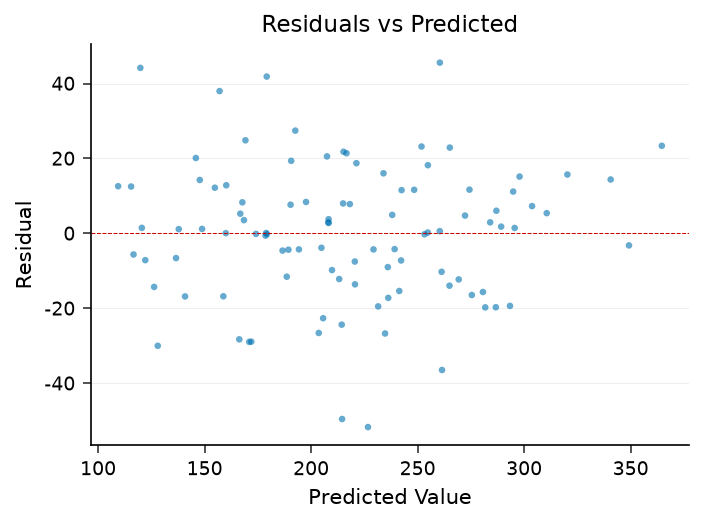

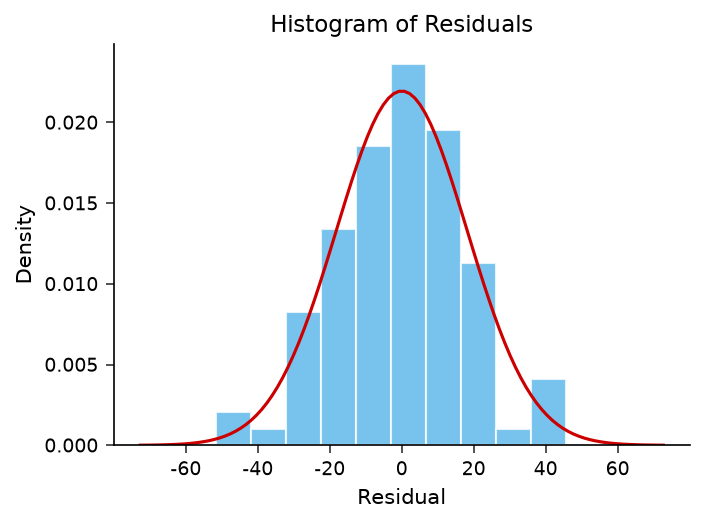

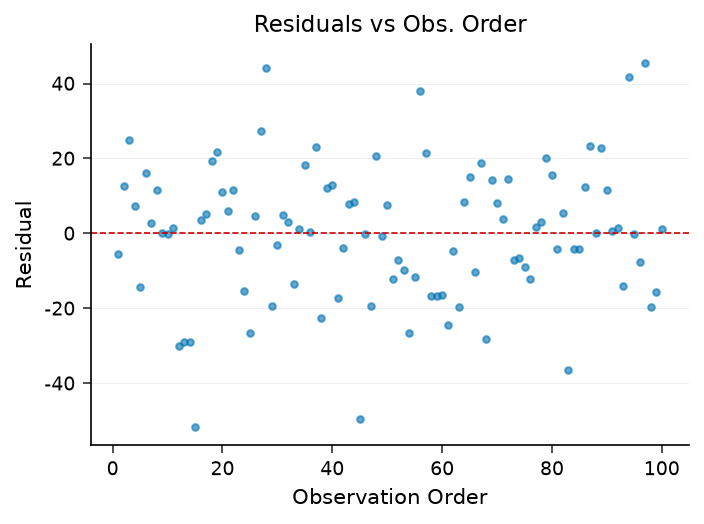

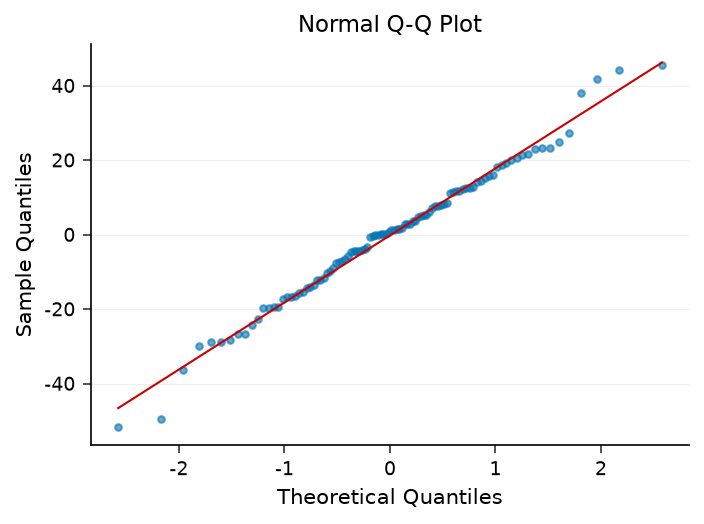

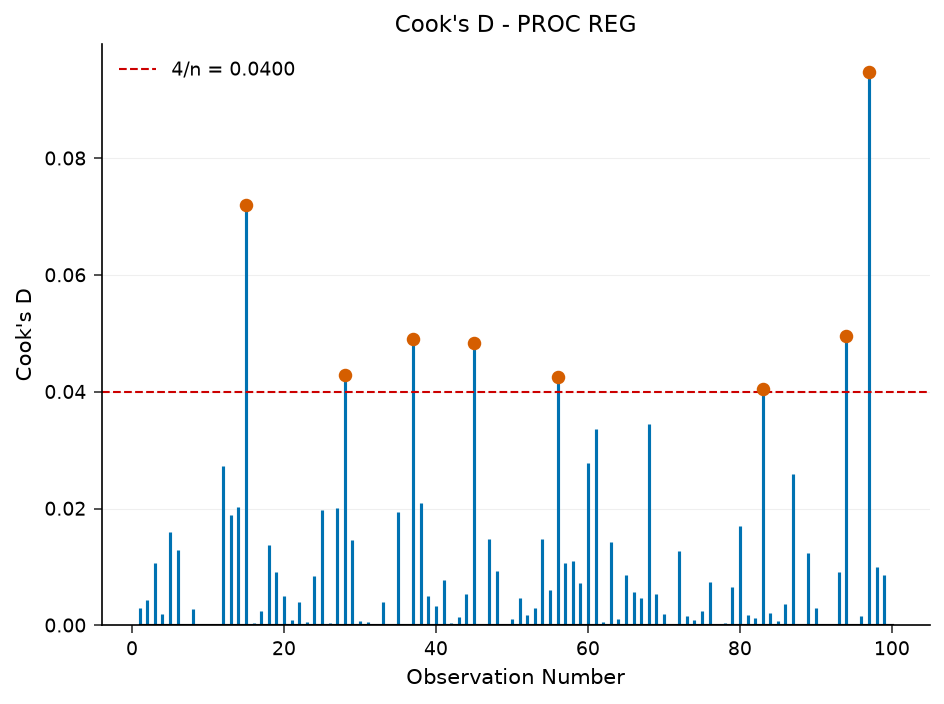

In [5]:
proc reg data=ws_dummies noprint;
    model units = price discount_pct comp_price disp feat
                  cat_bev cat_gro cat_hh email_spend social_spend holiday;
    output out=sales_scored p=pred r=resid;
run;

proc print data=sales_scored(obs=8) noobs;
    var category price promo role units pred resid;
run;

proc glmselect data=ws_dummies;
    model units = price discount_pct comp_price disp feat
                  cat_bev cat_gro cat_hh email_spend social_spend holiday;
    selection method=none;
    code file='demand_score.sas';
run;

## Interpreting the results

The stepwise model selected on the **validation** partition isolates the levers that genuinely move demand rather than ones that merely fit training noise:

- **Discount depth** carries the largest standardized coefficient (about +0.71): a deeper temporary price reduction is the single strongest driver of unit sales, confirming meaningful price elasticity in these categories. The focused `REG` refit echoes this with a discount coefficient near +220 units per unit of `discount_pct`.
- **Promotion type** matters: in the refit, feature promotions add roughly +68 units and display about +39, both highly significant, and the selection path enters a **discount × feature interaction** — a deep discount works hardest when paired with a feature.
- **Category** shifts the baseline strongly (Beverage well above the Snack reference, HouseHold below it), exactly as the data-generating process intends.
- **Marketing spend** contributes modest, diminishing lift (email about +3.2 units, social about +1.9), while a higher competitor price tends to lift our demand — the classic cross-price effect.
- **Holiday weeks** raise the baseline, consistent with seasonal demand.

The VIF diagnostics are informative rather than a clean bill of health: `price` (VIF ≈ 15) and `comp_price` (VIF ≈ 14) show **substantial multicollinearity**, which is expected because list price, discount depth, and competitor price are all anchored to the same base price. The remaining predictors sit comfortably below 3. A pricing analyst would read this as a caution that the individual price/competitor-price coefficients are less stable than discount and promotion effects — a realistic finding worth surfacing before the model informs decisions. Because the final model was chosen by validation error and the scored data set carries the role indicator, the team can report honest **test-set** accuracy before the exported scoring code is promoted into the pricing and promotion-planning workflow.